# Anisotropic MeanFlow with α_t Interpolant

**Interpolant formulation:** `z_t = (1 - α_t) ⊙ x + α_t ⊙ ε`

where:
- `α_t = 0` for observed pixels (no noise, stays at data)
- `α_t = t` for masked pixels (interpolates from 0→1 as t goes from 0→1, i.e., from data→noise)
- `⊙` denotes element-wise (Hadamard) product
- At t=0: all pixels are data; At t=1: masked pixels are noise, observed pixels stay as data

**Key features:**
- Spatial conditioning: α_t is interpolated to match each U-Net layer resolution
- Fixed mask structure (box inpainting)
- Modified MeanFlow loss with Jacobian correction terms

In [25]:
# !pip install -q -U einops datasets matplotlib tqdm

%load_ext autoreload
%autoreload 2

import os
import torch
from torch import nn
from torch import einsum
import torch.nn.functional as F
import numpy as np
from torchvision.datasets import MNIST, CIFAR10, CelebA
import torchvision.transforms.v2 as transforms
import matplotlib.pyplot as plt
from IPython import display
from tqdm import tqdm

import math
from inspect import isfunction
from functools import partial

from einops import rearrange

from training.networks_amf import SongUNet, AMFPrecond
from torch_utils.resizer import Resizer

import scipy.ndimage
import zipfile

from PIL import Image
import pickle

import lpips
from IPython.display import display, clear_output

plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['image.cmap'] = 'gray'

os.makedirs('save', exist_ok=True)

seed = 42
from baselines.flow_priors import FLOW_PRIORS
from baselines.d_flow import D_FLOW
from baselines.ot_ode import OT_ODE, DegradationWrapper, make_args
from baselines.flow_priors import FLOW_PRIORS, make_args as fp_make_args


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Utility Functions

In [3]:
def grid(array, ncols=8):
    array = np.pad(array, [(0,0),(1,1),(1,1),(0,0)], 'constant')
    nindex, height, width, intensity = array.shape
    ncols = min(nindex, ncols)
    nrows = (nindex+ncols-1)//ncols
    r = nrows*ncols - nindex
    arr = np.concatenate([array]+[np.zeros([1,height,width,intensity])]*r)
    result = (arr.reshape(nrows, ncols, height, width, intensity)
              .swapaxes(1,2)
              .reshape(height*nrows, width*ncols, intensity))
    return np.pad(result, [(1,1),(1,1),(0,0)], 'constant')

class NextDataLoader(torch.utils.data.DataLoader):
    def __next__(self):
        try:
            return next(self.iterator)
        except:
            self.iterator = self.__iter__()
            return next(self.iterator)

def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

class Blurkernel(torch.nn.Module):
    def __init__(self, blur_type='gaussian', kernel_size=5, std=3.0, device=None, channels=3):
        super().__init__()
        self.blur_type = blur_type
        self.kernel_size = kernel_size
        self.std = std
        self.device = device
        self.channels = channels
        self.seq = torch.nn.Sequential(
            torch.nn.ReflectionPad2d(self.kernel_size//2),
            torch.nn.Conv2d(self.channels, self.channels, self.kernel_size, stride=1, padding=0, bias=False, groups=self.channels)
        )

        self.weights_init()

    def forward(self, x):
        return self.seq(x)

    def transpose(self, x):
        return self.seq(x)

    def weights_init(self):
        if self.blur_type == "gaussian":
            n = np.zeros((self.kernel_size, self.kernel_size))
            n[self.kernel_size // 2,self.kernel_size // 2] = 1
            k = scipy.ndimage.gaussian_filter(n, sigma=self.std)
            k = torch.from_numpy(k)
            self.k = k
            for name, f in self.named_parameters():
                f.data.copy_(k)

    def update_weights(self, k):
        if not torch.is_tensor(k):
            k = torch.from_numpy(k).to(self.device)
        for name, f in self.named_parameters():
            f.data.copy_(k)

    def get_kernel(self):
        return self.k
    
    def get_fourier(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        half = self.kernel_size // 2
        kernel_padded[:half+1, :half+1] = self.k[half:, half:]
        kernel_padded[-half:, :half+1] = self.k[:half, half:]
        kernel_padded[:half+1, -half:] = self.k[half:, :half]
        kernel_padded[-half:, -half:] = self.k[:half, :half]
        k_fourier = torch.fft.fft2(kernel_padded, dim=[-1, -2])
        return k_fourier
        
    def get_fourier_shift(self, img_dim):
        kernel_padded = torch.zeros((img_dim, img_dim))
        kernel_padded[:self.kernel_size, :self.kernel_size] = self.k
        k_fourier = torch.fft.fftshift(torch.fft.fft2(kernel_padded), dim=[-1, -2])
        return k_fourier

    def get_inverse_fourier(self, img_dim):
        f_kernel = self.get_fourier(img_dim)
        return f_kernel ** -1
    
    def get_inverse_reg_fourier(self, img_dim, epsilon = 1e-8):
        f_kernel = self.get_fourier(img_dim)
        f_kernel_mag_sq = torch.abs(f_kernel)**2
        stabilized_denominator = f_kernel_mag_sq + epsilon
        inverse_filter_fourier = torch.conj(f_kernel) / stabilized_denominator
        return inverse_filter_fourier

class SuperResolutionOperator(nn.Module):
    def __init__(self, in_shape, scale_factor, device):
        super().__init__()
        self.device = device
        self.up_sample = partial(F.interpolate, scale_factor=scale_factor)
        self.down_sample = Resizer(in_shape, 1/scale_factor).to(device)

    def forward(self, data, **kwargs):
        return self.down_sample(data)

    def transpose(self, data, **kwargs):
        return self.up_sample(data)

    def project(self, data, measurement, **kwargs):
        return data - self.transpose(self.forward(data)) + self.transpose(measurement)


class CelebAZip(torch.utils.data.Dataset):
    def __init__(self, zip_path, partition_file, split='test', transform=None):
        self.zip_path = zip_path
        self.transform = transform
        split_map = {'train': 0, 'val': 1, 'test': 2}
        split_id = split_map[split]

        with open(partition_file) as f:
            entries = [line.strip().split() for line in f]

        valid = {e[0].replace('.jpg', '.png') for e in entries if int(e[1]) == split_id}

        with zipfile.ZipFile(zip_path) as z:
            self.names = sorted(n for n in z.namelist() if n in valid)

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        with zipfile.ZipFile(self.zip_path) as z:
            with z.open(self.names[idx]) as f:
                img = Image.open(f).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, 0


## Mask Generation

Generate binary masks where:
- `mask = 1`: observed pixels
- `mask = 0`: pixels to inpaint

**Random box sizes:** During training, box sizes are randomized from 1 pixel to the full image size for better generalization!

In [4]:
def generate_box_mask(batch_size, channels, height, width, box_size=16, device='cuda'):
    """
    Generate center box masks for inpainting.
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked (center box)
    """
    mask = torch.ones(batch_size, channels, height, width, device=device)
    start = (height - box_size) // 2
    end = start + box_size
    mask[:, :, start:end, start:end] = 0
    return mask

def generate_random_box_mask(batch_size, channels, height, width, min_box_size=1, max_box_size=None, device='cuda'):
    """
    Generate center box masks with RANDOM box sizes for each sample in the batch.
    
    Args:
        batch_size: number of samples
        channels: number of channels
        height, width: image dimensions
        min_box_size: minimum box size (default: 1 pixel)
        max_box_size: maximum box size (default: full image size)
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked (center box with random size per sample)
    """
    if max_box_size is None:
        max_box_size = min(height, width)
    
    masks = []
    for _ in range(batch_size):
        # Randomly sample box size for this sample
        box_size = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
        
        # Create mask for this sample
        mask = torch.ones(channels, height, width, device=device)
        start = (height - box_size) // 2
        end = start + box_size
        mask[:, start:end, start:end] = 0
        masks.append(mask)
    
    return torch.stack(masks, dim=0)

def generate_random_mask(batch_size, channels, height, width, mask_ratio=0.5, device='cuda'):
    """
    Generate random pixel masks for inpainting.
    
    Args:
        mask_ratio: proportion of pixels to mask
    
    Returns:
        mask: [B, C, H, W], 1 = observed, 0 = masked
    """
    mask = torch.rand(batch_size, channels, height, width, device=device)
    mask = (mask > mask_ratio).float()
    return mask

def generate_box_alpha(alpha, img_size):
    size_box = int(img_size / alpha.shape[-1])
    noise_mask = alpha.repeat_interleave(size_box, dim=2).repeat_interleave(size_box, dim=3)  # Upsample to (5, 1, 4, 4) for 4 boxespr
    return noise_mask

## Alpha Schedule and Interpolant

**Alpha schedule (Standard Diffusion Convention):**
- `α_t = (1 - mask) * t`
- Observed pixels (mask=1): `α_t = 0` (always at data)
- Masked pixels (mask=0): `α_t = t` (goes from 0→1, i.e., data→noise)

**Interpolant:**
- `z_t = (α_t) ⊙ x + (1 - α_t) ⊙ ε`
- At t=1: `z_1 = x` (all data)
- At t=0: `z_0 = mask ⊙ x + (1-mask) ⊙ ε` (observed=data, masked=noise)

**Velocity:**
- `dz_t/dt = -x·dα_t/dt + ε·dα_t/dt = (ε - x)·dα_t/dt`
- `dα_t/dt = (1 - mask)` (only masked pixels change)
- `v = (1 - mask) ⊙ (ε - x)`

In [5]:
# def compute_alpha_t(t, mask):
#     """
#     Compute α_t from time and mask.

#     Args:
#         t: time parameter [B, 1, 1, 1], ranges from 0 (data) to 1 (noise)
#         mask: binary mask [B, C, H, W], 1 = observed, 0 = masked

#     Returns:
#         α_t: [B, C, H, W]
#     """
#     # α_t = (1 - mask) * (1 -t
#     # Observed (mask=1): α_t = 1 (always at data)
#     # Masked (mask=0): α_t = t (goes from data to noise)
#     # alpha_t = mask + (1 - mask) * t
#     alpha_t = (1 - mask) * (1 - t)
#     return alpha_t

def compute_alpha_t(t, mask):
    """
    Compute α_t from time and mask.
    Convention: higher alpha = cleaner (alpha=1 is data, alpha=0 is noise)
    Args:
        t: time parameter [B, 1, 1, 1], ranges from 0 (noise) to 1 (data)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked
    Returns:
        α_t: [B, C, H, W]
        - Observed (mask=1): α_t = 1 (always clean)
        - Masked  (mask=0): α_t = t (interpolates noise→data as t: 0→1)
    """
    alpha_t = mask + (1 - mask) * t
    return alpha_t


def sample_interpolant(x, t, mask, eps=None):
    """
    Sample from the interpolant: z_t = α_t ⊙ x + (1 - α_t) ⊙ ε
    Convention: higher alpha = cleaner (alpha=1 is data, alpha=0 is noise)
    Args:
        x: clean data [B, C, H, W]
        t: time [B, 1, 1, 1], ranges from 0 (noise) to 1 (data)
        mask: binary mask [B, C, H, W], 1 = observed, 0 = masked
        eps: noise (optional, will sample if not provided)
    Returns:
        z_t: interpolated sample [B, C, H, W]
        alpha_t: interpolation coefficients [B, C, H, W]
        eps: noise used [B, C, H, W]
        v_true: true velocity field [B, C, H, W]
        drift: (x - eps) [B, C, H, W]
    """
    if eps is None:
        eps = torch.randn_like(x)

    # alpha=1 clean, alpha=0 noise
    # Observed (mask=1): alpha=1 always → z = x
    # Masked  (mask=0): alpha=t → t=1: z=x, t=0: z=eps
    alpha_t = compute_alpha_t(t, mask)

    # Interpolant: z_t = alpha_t * x + (1 - alpha_t) * eps
    z_t = alpha_t * x + (1 - alpha_t) * eps

    # Velocity: dz/dt = d(alpha_t)/dt * (x - eps)
    # d(alpha_t)/dt = (1 - mask)
    drift = x - eps
    v_true = (1 - mask) * drift

    return z_t, alpha_t, eps, v_true, drift

In [6]:
@torch.inference_mode()
def sample(net, alpha_start, x_observed=None, num_steps=1, device='cuda'):
    """
    alpha_start: [B, C, H, W]  initial per-pixel alpha
                  (0 for masked pixels, 1 for observed pixels)
    x_observed:  [B, C, H, W]  known pixel values

    Integrates from alpha_start → 1 per pixel.
    """
    B, C, H, W = alpha_start.shape

    if x_observed is None:
        x_observed = torch.zeros(B, C, H, W, device=device)

    eps   = torch.randn(B, C, H, W, device=device)
    z   = alpha_start * x_observed + (1 - alpha_start) * eps
    x_init = z.clone()

    t_values = torch.linspace(0.0, 1.0, num_steps + 1, device=device)

    for i in range(num_steps):
        t_cur  = t_values[i]
        t_next = t_values[i + 1]
        # per-pixel alpha: interpolate from alpha_start to 1
        alpha_r = alpha_start + t_cur  * (1 - alpha_start)  # (B, C, H, W)
        alpha_t = alpha_start + t_next * (1 - alpha_start)

        v_pred = net(z, alpha_r[:, :1], alpha_t[:, :1])
        z = z + (alpha_t - alpha_r) * v_pred

    return z, x_init

## Run Training

In [18]:
device = 'cuda:6' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

data = 'celeba'  # 'mnist' or 'cifar10' or 'celeba'

# Create model
if data == 'afhq':
    img_size = 192
    net = AMFPrecond(
        img_resolution=img_size,
        img_channels=3,
        model_channels=128,  # 64 or 128,  # Base multiplier for the number of channels.
        channel_mult=[1, 2, 3, 4],    # Per-resolution multipliers for the number of channels.
        num_blocks=3,
        attn_resolutions=[16,8],
        use_weight=True,
        anisotropic_noise=False,
    ).to(device)
elif data == 'celeba':
    # img_size = 64
    # net = AMFPrecond(
    #     img_resolution=img_size,
    #     img_channels=3,
    #     model_channels=128,  # 64 or 128,  # Base multiplier for the number of channels.
    #     channel_mult=[1, 2, 2, 2],    # Per-resolution multipliers for the number of channels.
    #     num_blocks=4,
    #     use_weight=True,
    #     anisotropic_noise=False,
    # ).to(device)
    img_size = 128
    net = AMFPrecond(
        img_resolution=img_size,
        img_channels=3,
        model_channels=128,  # 64 or 128,  # Base multiplier for the number of channels.
        channel_mult=[1, 2, 3, 4],    # Per-resolution multipliers for the number of channels.
        num_blocks=3,
        attn_resolutions=[16,8],
        use_weight=True,
        anisotropic_noise=False,
    ).to(device)

print(f"Model parameters: {sum(p.numel() for p in net.parameters()):,}")
loss_fn_alex = lpips.LPIPS(net='alex').to(device) # best forward scores.to(device)

Using device: cuda:6
Model parameters: 117,043,331
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/nvidia/diffusion/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/nvidia/diffusion/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/nvidia/diffusion/lib/python3.12/site-packages/lpips/weights/v0.1/alex.pth


## Test and Visualize

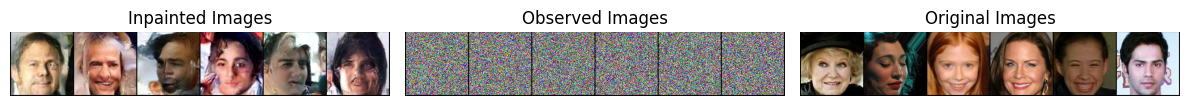

In [20]:
if data == 'cifar10':
    with open('/home/nvidia/easy_meanflow/logs/aniso_flow_map/lsd_correct_partition/00024-cifar10-32x32-uncond-ddpmpp-mf-gpus4-batch512-fp32/network-snapshot-100000.pkl', 'rb') as f:
        checkpoint = pickle.load(f)
elif data == 'celeba':
    with open('/home/nvidia/easy_meanflow/logs/aniso_flow_map/lsd/00054-celeba-128x128-uncond-ddpmpp-mf-gpus8-batch128-fp32/network-snapshot-087584.pkl', 'rb') as f:
        checkpoint = pickle.load(f)
elif data == 'afhq':
    with open('/home/nvidia/easy_meanflow/logs/aniso_flow_map/lsd/00055-afhq-cat-192x192-uncond-ddpmpp-mf-gpus8-batch64-fp32/network-snapshot-007507.pkl', 'rb') as f:
        checkpoint = pickle.load(f)

net = checkpoint['ema']  # or 'net' — check keys below
net.eval().to(device)


# Test
batch_size = 6

test_mask = []
min_box_size = 1
for _ in range(batch_size):
    # box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    box_size_i = 15
    # test_mask.append(generate_random_mask(1, 1, img_size, img_size, mask_ratio=0.7, device=device))
    test_mask.append(generate_random_box_mask(1, 1, img_size, img_size, min_box_size=box_size_i, max_box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]

if data == 'mnist':
    test_dataset = MNIST(
        'data',
        train=False,
        transform=transforms.Compose(list(filter(None, [
            transforms.Resize((img_size, img_size)) if img_size is not None else None,
            transforms.Grayscale(),
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize([0.5], [0.5]),
        ]))),
        download=True
    )
elif data == 'cifar10':
    test_dataset = CIFAR10(
        'data',
        train=False,
        transform=transforms.Compose(list(filter(None, [
            transforms.Resize((img_size, img_size)) if img_size is not None else None,
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ]))),
        download=True
    )
elif data == 'celeba':
    test_dataset = CelebAZip(
        zip_path='/home/nvidia/easy_meanflow/data/celeba/celeba-128x128.zip',
        partition_file='/home/nvidia/easy_meanflow/data/celeba/list_eval_partition.txt',
        split='test',
        transform=transforms.Compose([
            transforms.ToImage(),
            transforms.ToDtype(torch.float32, scale=True),
            transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
        ])
    )
elif data == 'afhq':
    from training.dataset import ImageFolderDataset
    _base = ImageFolderDataset(
        path='/home/nvidia/easy_meanflow/data/afhq-cat-192x192.zip',
        split='test',
        train_ratio=0.9,
    )
    class _AFHQWrapper(torch.utils.data.Dataset):
        def __len__(self): return len(_base)
        def __getitem__(self, idx):
            img_np, label = _base[idx]  # CHW uint8
            return torch.from_numpy(img_np).float() / 127.5 - 1, label
    test_dataset = _AFHQWrapper()

dataloader = NextDataLoader(
    test_dataset, batch_size, num_workers=1, prefetch_factor=2, pin_memory=True
)
img = next(dataloader)[0]  # [1, 1, 32, 32]

num_steps = 1
alpha_start = torch.zeros_like(img).to(device)  # Start with all noise (alpha=0)
with torch.no_grad():
    z, x_init = sample(net, alpha_start, device=device, num_steps=num_steps)

# Visualize
x_reconstr = ((z+1)/2).detach().permute(0,2,3,1).clamp(0,1)
x_obs = ((x_init + 1) / 2).permute(0,2,3,1).clamp(0, 1).cpu()
x_original = ((img.detach() + 1) / 2).permute(0,2,3,1).cpu()

plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.title('Inpainted Images')
plt.imshow(grid(x_reconstr.cpu()).squeeze())
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Observed Images')
plt.imshow(grid(x_obs).squeeze())
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Original Images')
plt.imshow(grid(x_original.cpu()).squeeze())
plt.axis('off')

plt.tight_layout()
plt.show()

## Inpainting

In [ ]:
# Compute PSNR
def compute_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # Images converted to [0, 1] before PSNR
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item(), mse.item()

seed = 200
# N = 10  # same for everyone
noise_std = 1e-3

torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

test_mask = []
min_box_size = 1
for _ in range(batch_size):
    # box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    box_size_i = 50
    # test_mask.append(generate_random_mask(1, 1, img_size, img_size, mask_ratio=0.6, device=device))
    test_mask.append(generate_random_box_mask(1, 1, img_size, img_size, min_box_size=box_size_i, max_box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]
if data == 'cifar10' or data == 'celeba':
    # Repeat the mask across 3 channels for CIFAR10
    test_mask = test_mask.repeat(1, 3, 1, 1)

# Fix noisy image once
noisy_img = test_mask * img.to(device) + noise_std * torch.randn_like(img.to(device))
alpha = 0.1e-1  # Exponent in the learning rate

with torch.no_grad():
    results = {}
    results_lpips = {}
    x_intermediate = {}
    for N in [100]:

        for lookahead in [0.0, 0.2, 0.5, 1.0]:
            # fig, ax = plt.subplots()
            torch.manual_seed(seed)
            np.random.seed(seed)
            torch.cuda.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            x = torch.zeros((batch_size, 3, img_size, img_size)).to(device)
            # x = torch.randn((batch_size, 1, img_size, img_size)).to(device)
            
            for i in range(N):
                t = torch.ones(len(x), device=device) * (i / N)
                t_target = torch.clamp(t + lookahead, max=1.0)
                
                # Data fidelity
                lr_t =  (1 - t).view(-1, 1, 1, 1)**alpha
                z = x - lr_t * test_mask * (test_mask * x - noisy_img)

                # Interpolation
                # wit/h torch.no_grad():
                z_tilde = t.view(-1,1,1,1) * z + \
                    torch.randn_like(x) * (1 - t.view(-1,1,1,1))
                    
                # Denoising with lookahead
                # print(t)
                x = z_tilde + (1 - t.view(-1,1,1,1)) * \
                    net(z_tilde, t.view(-1,1,1,1), t_target.view(-1,1,1,1))

                # Plot the current image
                if i % 10 == 0 or i == N - 1:
                    x_intermediate[(N, lookahead, i)] = x.detach().cpu()
                    # clear_output(wait=True)
                    # ax.imshow(torch.clip((x[0].cpu()),
                    #         0, 1).permute(1, 2, 0), vmin=0, vmax=1)
                    # ax.axis('off')
                    # ax.set_title(
                    #     'Reconstructed image at time t={:4.2f}'.format((1 / N) * i))
                    # display(fig)

            # clear_output(wait=False)
                
            x_ = torch.clamp((x.detach() + 1)/2, 0, 1)
            psnr, mse = compute_psnr(x_, ((img + 1)/2).to(device))
            results[(N, lookahead)] = psnr
            print(f"N={N}, lookahead={lookahead:.1f} | PSNR={psnr:.2f}dB")
            print(f"N={N}, lookahead={lookahead:.1f} | MSE={mse:.5f}")
            with torch.no_grad():
                lpips_score = 0.0
                for idx in range(x.shape[0]):
                    lpips_score += loss_fn_alex(x_[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
            results_lpips[(N, lookahead)] = lpips_score / x.shape[0]
            print(f"N={N}, lookahead={lookahead:.1f} | LPIPS={results_lpips[(N, lookahead)]:.4f}")

            plt.figure(figsize=(12, 12))
            plt.subplot(1, 2, 1)
            plt.title(f'Rec. - Lookahead {lookahead}, N={N}')
            plt.imshow(grid(((x.detach() + 1) / 2).clamp(0, 1).permute(0,2,3,1).cpu()).squeeze())
            plt.axis('off')

            plt.subplot(1, 2, 2)
            plt.title('Observed Images')
            plt.imshow(grid(((noisy_img + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
            plt.axis('off')

In [ ]:
s_values = [0.3, 0.5, 0.7]  # try multiple source times
delta_s_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5, 1.0]
# clamp t = s + delta_s <= 1
M = 50

x1 = img.to(device)
fig, axes = plt.subplots(1, len(s_values), figsize=(14, 4))

for ax, s_val in zip(axes, s_values):
    mse_list = []

    with torch.no_grad():
        for delta_s in delta_s_values:
            t_val = min(s_val + delta_s, 1.0)
            # skip if no room for lookahead
            if t_val <= s_val:
                continue
            t_src = torch.full((batch_size,1,1,1), s_val, device=device)
            t_tgt = torch.full((batch_size,1,1,1), t_val, device=device)

            mse_accum = 0.0
            for _ in range(M):
                x0 = torch.randn_like(x1)
                # x_s is on the interpolant at time s
                xs = s_val * x1 + (1 - s_val) * x0
                v = net(xs, t_src, t_tgt)
                x1_hat = xs + (1 - s_val) * v
                mse_accum += ((x1_hat - x1) ** 2).mean().item()

            mse_list.append(mse_accum / M)
            print(f"s={s_val}, Δs={delta_s:.2f} | MSE={mse_accum/M:.5f}")

    ax.plot(delta_s_values[:len(mse_list)], mse_list, 'o-', linewidth=2)
    ax.set_xlabel('Lookahead $\\Delta s$')
    ax.set_ylabel('MSE')
    ax.set_title(f'$s = {s_val}$')
    ax.set_yscale('log')

plt.suptitle('Denoiser MSE vs lookahead $\\Delta s$ (Theorem 1)')
plt.tight_layout()
plt.savefig('denoiser_mse_vs_lookahead.pdf')
plt.show()

In [ ]:
# Given the dictionary x_intermediate, I want 3 plots: one for each lookahead, where each row has all the x_intermediate

for lookahead in [0.0, 0.5, 1.0]:
    plt.figure(figsize=(12, 8))
    for i, N in enumerate([100]):
        for j, step in enumerate(sorted([key[2] for key in x_intermediate.keys() if key[0] == N and key[1] == lookahead])):
            plt.subplot(len([100]), len(sorted([key[2] for key in x_intermediate.keys() if key[0] == N and key[1] == lookahead])), i*len(sorted([key[2] for key in x_intermediate.keys() if key[0] == N and key[1] == lookahead])) + j + 1)
            plt.title(f'N={N}, lookahead={lookahead}, step={step}')
            plt.imshow(grid(torch.clamp(x_intermediate[(N, lookahead, step)], 0, 1).permute(0,2,3,1)).squeeze())
            plt.axis('off')
    plt.tight_layout()
    plt.show()

## Deblurring

In [ ]:
# --- Baseline: FLOW_PRIORS ---
# d_flow = D_FLOW(net=net, device=device, loss_fn_lpips=loss_fn_alex)
# d_flow.run_method(img=img, noisy_img=noisy_img, degradation=test_mask)

N=100, lookahead=0.0 | PSNR=27.54dB
N=100, lookahead=0.0 | MSE=0.00176
N=100, lookahead=0.0 | LPIPS=0.3780


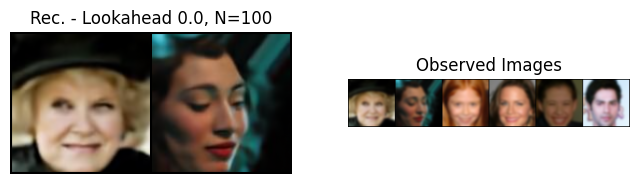

In [21]:
# Compute PSNR
import PIL


def compute_psnr(img1, img2):
    mse = F.mse_loss(img1, img2)
    if mse == 0:
        return float('inf')
    max_pixel = 1.0  # Images converted to [0, 1] before PSNR
    psnr = 20 * torch.log10(max_pixel / torch.sqrt(mse))
    return psnr.item(), mse.item()

seed = 30
# N = 10  # same for everyone
noise_std = 1e-3

test_mask = []
min_box_size = 1
for _ in range(batch_size):
    # box_size_i = torch.randint(min_box_size, max_box_size + 1, (1,)).item()
    box_size_i = 10
    # test_mask.append(generate_random_mask(1, 1, img_size, img_size, mask_ratio=0.7, device=device))
    test_mask.append(generate_random_box_mask(1, 1, img_size, img_size, min_box_size=box_size_i, max_box_size=box_size_i, device=device))
test_mask = torch.cat(test_mask, dim=0)  # [8, 1, H, W]

test_mask = Blurkernel(blur_type='gaussian', kernel_size=45, std=3.0, device=device, channels=3).to(device)
# test_mask = SuperResolutionOperator(in_shape=(batch_size, 3, img_size, img_size), scale_factor=8, device=device)
# Fix noisy image once
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

N = 100
lookahead = 0.0
deg  = DegradationWrapper(test_mask)   # Blurkernel is self-adjoint
args = make_args(steps_ode=N, lookahead=lookahead, alpha=0.05)

solver = OT_ODE(net, device, args)
x, noisy_img = solver.solve(img, deg, sigma_noise=noise_std)

results = {}
results_lpips = {}

x_ = torch.clamp((x.detach() + 1)/2, 0, 1)
psnr, mse = compute_psnr(x_, ((img + 1)/2).to(device))
results[(N, lookahead)] = psnr
print(f"N={N}, lookahead={lookahead:.1f} | PSNR={psnr:.2f}dB")
print(f"N={N}, lookahead={lookahead:.1f} | MSE={mse:.5f}")
with torch.no_grad():
    lpips_score = 0.0
    for idx in range(x.shape[0]):
        lpips_score += loss_fn_alex(x_[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
results_lpips[(N, lookahead)] = lpips_score / x.shape[0]
print(f"N={N}, lookahead={lookahead:.1f} | LPIPS={results_lpips[(N, lookahead)]:.4f}")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title(f'Rec. - Lookahead {lookahead}, N={N}')
plt.imshow(grid(((x[0:2].detach() + 1) / 2).clamp(0, 1).permute(0,2,3,1).cpu()).squeeze())
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Observed Images')
plt.imshow(grid(((noisy_img + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
plt.axis('off')

plt.savefig(f'reconstruction_lookahead_{lookahead}_N_{N}_deblurring.pdf')

FLOW_PRIORS | PSNR=24.86dB
FLOW_PRIORS | MSE=0.00327
FLOW_PRIORS | LPIPS=0.2718


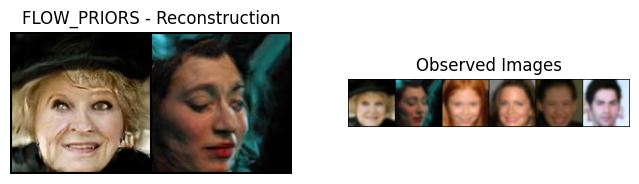

In [32]:
# deg, img, noisy_img, noise_std, loss_fn_alex already defined in the OT_ODE cell above
fp_args = fp_make_args(N=100, K=1, lmbda=1.0e4, eta=1e-2)

fp_solver = FLOW_PRIORS(net, device, fp_args)
x_fp, noisy_img = fp_solver.solve(img, deg, sigma_noise=noise_std)

x_fp_ = torch.clamp((x_fp.detach() + 1) / 2, 0, 1)
psnr_fp, mse_fp = compute_psnr(x_fp_, ((img + 1) / 2).to(device))
print(f"FLOW_PRIORS | PSNR={psnr_fp:.2f}dB")
print(f"FLOW_PRIORS | MSE={mse_fp:.5f}")
with torch.no_grad():
    lpips_fp = sum(
        loss_fn_alex(x_fp_[i:i+1].to(device), img[i:i+1].to(device)).item()
        for i in range(x_fp_.shape[0])
    ) / x_fp_.shape[0]
print(f"FLOW_PRIORS | LPIPS={lpips_fp:.4f}")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title('FLOW_PRIORS - Reconstruction')
plt.imshow(grid(x_fp_[0:2].permute(0,2,3,1).cpu()).squeeze())
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Observed Images')
plt.imshow(grid(((noisy_img + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
plt.axis('off')

plt.savefig('reconstruction_flow_priors_deblurring.pdf')
plt.show()

DPS ODE | PSNR=20.67dB
DPS ODE | MSE=0.00857
DPS ODE | LPIPS=0.3006


(-0.5, 781.5, 131.5, -0.5)

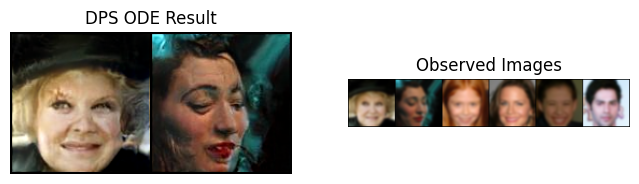

In [36]:
seed = 30
# N = 10  # same for everyone
noise_std = 1e-3

test_mask = Blurkernel(blur_type='gaussian', kernel_size=45, std=3.0, device=device, channels=3).to(device)
# test_mask = SuperResolutionOperator(in_shape=(batch_size, 3, img_size, img_size), scale_factor=8, device=device)
# Fix noisy image once
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

noisy_img = test_mask(img.to(device)) 
noisy_img = noisy_img + noise_std * torch.randn_like(noisy_img)

def dps_ode(noisy_img, img, deg, net, num_steps=100, alpha=1.0, eta=75, device='cuda'):
    x = torch.randn_like(img).clone().to(device)
    t_values = torch.linspace(0.0, 1.0, num_steps + 1, device=device)

    for i in range(num_steps):
        t_cur  = t_values[i].repeat(len(x))
        t_next = t_values[i + 1].repeat(len(x))
        dt     = t_next - t_cur

        prior = net(x, t_cur.view(-1,1,1,1), t_next.view(-1,1,1,1))

        # Tweedie denoised estimate
        x_tweedie = x + (1 - t_cur.view(-1,1,1,1)) * prior

        # DPS data-fidelity gradient
        x_leaf = x_tweedie.detach().requires_grad_(True)
        log_likelihood = -((noisy_img - deg(x_leaf)) ** 2).sum()
        lr_t = eta / (2 * torch.sqrt(-log_likelihood))
        lr_t = lr_t.detach()
        grad = torch.autograd.grad(log_likelihood, x_leaf)[0]

        # print(grad.shape, prior.shape, x.shape, dt.shape)

        x = x + dt.view(-1,1,1,1) * (lr_t * grad + prior)

    return x

dps_result = dps_ode(noisy_img, img, test_mask, net, num_steps=10, alpha=0.05, eta = 2000, device=device)
dps_result_ = torch.clamp((dps_result.detach() + 1) / 2, 0, 1)
psnr_dps, mse_dps = compute_psnr(dps_result_, ((img + 1)/2).to(device))
print(f"DPS ODE | PSNR={psnr_dps:.2f}dB")
print(f"DPS ODE | MSE={mse_dps:.5f}")
with torch.no_grad():
    lpips_score_dps = 0.0
    for idx in range(dps_result.shape[0]):
        lpips_score_dps += loss_fn_alex(dps_result_[idx:idx+1].to(device), img[idx:idx+1].to(device)).item()
print(f"DPS ODE | LPIPS={lpips_score_dps / dps_result.shape[0]:.4f}")

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.title(f'DPS ODE Result')
plt.imshow(grid(((dps_result[0:2].detach() + 1) / 2).clamp(0, 1).permute(0,2,3,1).cpu()).squeeze())
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Observed Images')
plt.imshow(grid(((noisy_img + 1) / 2).clamp(0, 1).permute(0,2,3,1).detach().cpu()).squeeze())
plt.axis('off')